In [6]:

import sys
import os
import pandas as pd
import numpy as np

sys.path.append(os.path.abspath(".."))

from src.preprocess import pull_pitcher_data
from datetime import date
from dateutil.relativedelta import relativedelta

pitcher_first = 'Logan'
pitcher_last = 'Webb'

end_date = date.today().strftime("%Y-%m-%d")
start_date = (date.today() - relativedelta(years=2)).strftime("%Y-%m-%d")


df = pull_pitcher_data(pitcher_first, pitcher_last,start_date, end_date)
df.shape

Gathering player lookup table. This may take a moment.
Gathering Player Data


(6682, 139)

In [10]:
#df2 = df[['pitch_type_map', 'balls', 'strikes', 'prev_pitch_1']]

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    log_loss,
    top_k_accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

import matplotlib.pyplot as plt


#df2 = df[['pitch_type_map', 'balls', 'strikes', 'batter_is_right', 'prev_pitch_1', 'prev_pitch_2', 'n_thruorder_pitcher']]
df2 = df.sort_values(["game_date", "at_bat_number"])
df3 = df2[['pitch_type_map','strikes', 'balls', 'outs_when_up', 'inning']]


#//////////////////////////////////////////////////////////////////////////////
from imblearn.combine import SMOTETomek

X = df3.drop(columns=["pitch_type_map"])
y = df3["pitch_type_map"]




X_train, X_test, y_train, y_test = train_test_split(X ,y, test_size=0.35, random_state=42)


#//////////////////////////////////////////////////////////////////////////////


# split_idx = int(len(df3) * 0.65)

# train_df = df3.iloc[:split_idx]
# test_df  = df3.iloc[split_idx:]

# X_train = train_df.drop(columns=["pitch_type_map"])
# y_train = train_df["pitch_type_map"]

# X_test  = test_df.drop(columns=["pitch_type_map"])
# y_test  = test_df["pitch_type_map"]
# Train-test split
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, random_state=42)
# X_train, X_test, y_train_raw, y_test_raw = train_test_split(
#     X, y, test_size=0.35, random_state=42, stratify=y
# )

class_mapping = {0: 'Fastball',
                1: 'Sinker',
                2: 'Curveball',
                3: 'Slider',
                4: 'Changeup',
                5: 'Cutter',
                6: 'Knuckleball'}

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)

# IMPORTANT: y_test might contain a class not in training if data is sparse.
# We'll handle that safely below.
# Try transforming; if unseen labels exist, we'll mask them out.
train_classes = label_encoder.classes_

mask_test_seen = y_test.isin(train_classes)
y_test_raw_seen = y_test[mask_test_seen]
X_test_seen = X_test.loc[mask_test_seen]

y_test = label_encoder.transform(y_test_raw_seen)

#############################################

lr_model = LogisticRegression(
    random_state=43,
    max_iter=1000,
    class_weight="balanced",
)
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test_seen)
y_proba = lr_model.predict_proba(X_test_seen)
model_classes_encoded = lr_model.classes_  
labels_for_metrics = model_classes_encoded

acc = accuracy_score(y_test, y_pred)


f1_w = f1_score(y_test, y_pred, average="weighted")
f1_m = f1_score(y_test, y_pred, average="macro")

print("Logistic Regression: ")

ll = log_loss(y_test, y_proba, labels=labels_for_metrics)

top2 = top_k_accuracy_score(y_test, y_proba, k=2, labels=labels_for_metrics)

print(f"Accuracy:          {acc:.4f}")
print(f"F1 (weighted):     {f1_w:.4f}")
print(f"F1 (macro):        {f1_m:.4f}")
print(f"Log Loss:          {ll:.4f}")
print(f"Top-2 Accuracy:    {top2:.4f}")




from sklearn.metrics import log_loss
import numpy as np

# Baseline: always predict training distribution
class_probs = np.bincount(y_train) / len(y_train)

baseline_probs = np.tile(class_probs, (len(y_test), 1))

baseline_ll = log_loss(y_test, baseline_probs, labels=np.arange(len(class_probs)))

print(f"Baseline Log Loss: {baseline_ll:.4f}")
print(f"Model Log Loss:    {ll:.4f}")
print(f"Improvement:       {baseline_ll - ll:.4f}")


#######################################################

import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, log_loss, top_k_accuracy_score

# --- (Optional but recommended) class weights via sample_weight ---
# This approximates "balanced" for multiclass by weighting each training row inversely to class frequency.
class_counts = np.bincount(y_train)
class_weights = (len(y_train) / (len(class_counts) * class_counts))
sample_weight = class_weights[y_train]

num_classes = len(np.unique(y_train))

xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=num_classes,
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=43,
    n_jobs=-1,
    eval_metric="mlogloss"
)

# Fit (use sample_weight if you want balancing; otherwise remove sample_weight=sample_weight)
xgb_model.fit(X_train, y_train, sample_weight=sample_weight)

# Predict / predict_proba
y_pred = xgb_model.predict(X_test_seen)
y_proba = xgb_model.predict_proba(X_test_seen)

# Class labels for metrics (encoded ints 0..K-1)
labels_for_metrics = np.arange(num_classes)

# Metrics
acc = accuracy_score(y_test, y_pred)
f1_w = f1_score(y_test, y_pred, average="weighted")
f1_m = f1_score(y_test, y_pred, average="macro")

ll = log_loss(y_test, y_proba, labels=labels_for_metrics)
top2 = top_k_accuracy_score(y_test, y_proba, k=2, labels=labels_for_metrics)
print("XGBoost: ")

print(f"Accuracy:          {acc:.4f}")
print(f"F1 (weighted):     {f1_w:.4f}")
print(f"F1 (macro):        {f1_m:.4f}")
print(f"Log Loss:          {ll:.4f}")
print(f"Top-2 Accuracy:    {top2:.4f}")

# ---- Baseline log loss (training distribution) ----
class_probs = np.bincount(y_train, minlength=num_classes) / len(y_train)
baseline_probs = np.tile(class_probs, (len(y_test), 1))
baseline_ll = log_loss(y_test, baseline_probs, labels=labels_for_metrics)

print(f"Baseline Log Loss: {baseline_ll:.4f}")
print(f"Model Log Loss:    {ll:.4f}")
print(f"Improvement:       {baseline_ll - ll:.4f}")





Logistic Regression: 
Accuracy:          0.3776
F1 (weighted):     0.4381
F1 (macro):        0.2918
Log Loss:          1.3018
Top-2 Accuracy:    0.6806
Baseline Log Loss: 1.0316
Model Log Loss:    1.3018
Improvement:       -0.2701
XGBoost: 
Accuracy:          0.4240
F1 (weighted):     0.4554
F1 (macro):        0.3100
Log Loss:          1.1716
Top-2 Accuracy:    0.7425
Baseline Log Loss: 1.0316
Model Log Loss:    1.1716
Improvement:       -0.1400


Classification Report:
              precision    recall  f1-score   support

    Fastball       0.55      0.74      0.63       813
      Sinker       0.42      0.38      0.40       829
      Slider       0.38      0.29      0.33       848
    Changeup       0.36      0.18      0.24       851
      Cutter       0.47      0.74      0.58       774

    accuracy                           0.46      4115
   macro avg       0.44      0.47      0.43      4115
weighted avg       0.44      0.46      0.43      4115



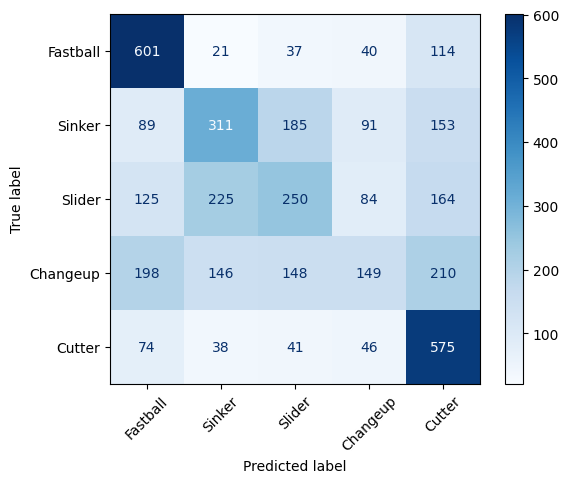

In [3]:
# print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_predictions))
# print("Logistic Regression F1 Score:", f1_score(y_test, lr_predictions, average='weighted'))



from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
class_labels = df['pitch_type_map'].unique()


print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=[class_mapping[c] for c in np.unique(y)]))
conf_matrix = confusion_matrix(y_test, y_pred)


disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=[class_mapping[c] for c in np.unique(y)])
disp.plot(cmap="Blues", xticks_rotation=45)

In [19]:
df.head()

,game_date,at_bat_number,pitch_type_map,balls,strikes,outs_when_up,home_score_diff,runner_on_first,inning_top,prev_pitch_1,...,pitch_number,inning,n_thruorder_pitcher,prev_pitch_was_fb,two_strike_count,hitters_count,last_two_pitches_same,prev_pitch_fb,prev_2_pitches_fb,is_fastball
4146,2024-06-07,4,1.0,1,2,0,0,0,0,3.0,...,4,1,1,0,1,0,1,0.0,0,1
4145,2024-06-07,4,3.0,1,2,0,0,0,0,1.0,...,5,1,1,0,1,0,0,1.0,0,0
4144,2024-06-07,5,0.0,0,0,1,0,0,0,3.0,...,1,1,1,0,0,1,0,0.0,0,1
4143,2024-06-07,5,1.0,0,1,1,0,0,0,0.0,...,2,1,1,1,0,1,0,1.0,0,1
4142,2024-06-07,5,3.0,1,1,1,0,0,0,1.0,...,3,1,1,0,0,1,0,1.0,0,0


In [23]:

X = df3.drop(columns=["pitch_type_map"])
y = df3["pitch_type_map"]

#resampling the data due to class imbalance

from imblearn.combine import SMOTETomek
smote_tomek = SMOTETomek(random_state=42)
X_resampled, y_resampled = smote_tomek.fit_resample(X, y)


X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.35, random_state=42)

class_mapping = {0: ' Fastball',
                1: 'Sinker',
                2: 'Cutter',
                3: 'Curveball',
                4: 'Slider',
                5: 'Changeup',
                6: 'Knuckle'}

label_encoder = LabelEncoder()

# Fit and transform y_train and y_test
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

Logistic Regression Accuracy: 0.404291553133515
Logistic Regression F1 Score: 0.39522531936586647
Classification Report:
              precision    recall  f1-score   support

    Fastball       0.33      0.26      0.29       742
      Sinker       0.67      0.53      0.59       712
   Curveball       0.39      0.21      0.27       753
      Slider       0.33      0.63      0.43       729

    accuracy                           0.40      2936
   macro avg       0.43      0.41      0.40      2936
weighted avg       0.43      0.40      0.40      2936



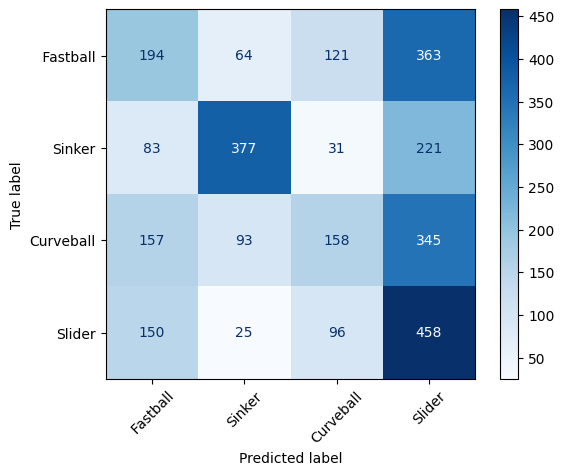

In [24]:
from sklearn.utils.class_weight import compute_class_weight



lr_model = LogisticRegression(random_state=43, max_iter=10000)
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)
y_pred_prob = lr_model.predict_proba(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_predictions))
print("Logistic Regression F1 Score:", f1_score(y_test, lr_predictions, average='weighted'))



from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
class_labels = df['pitch_type_map'].unique()


print("Classification Report:")
print(classification_report(y_test, lr_predictions, target_names=[class_mapping[c] for c in np.unique(y)]))
conf_matrix = confusion_matrix(y_test, lr_predictions)


disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=[class_mapping[c] for c in np.unique(y)])
disp.plot(cmap="Blues", xticks_rotation=45)

In [ ]:
from pybaseball import  playerid_lookup
from pybaseball import  statcast_pitcher
from pybaseball import  statcast
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, log_loss, top_k_accuracy_score

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

pitchers = [
"Logan Webb",
    "Garrett Crochet",
    "Cristopher Sánchez",
    "Max Fried",
    "Carlos Rodón",
    "Tarik Skubal",
    "Kevin Gausman",
    "Zac Gallen",
    "Framber Valdez",
    "Paul Skenes",
    "Zack Littell",
    "Bryan Woo",
    "Hunter Brown",
    "Merrill Kelly",
    "Jesús Luzardo",
    "Tanner Bibee",
    "Robbie Ray",
    "Nick Pivetta",
    "Luis Castillo",
    "Sonny Gray",
    "Jake Irvin",
    "Matthew Boyd",
    "Yusei Kikuchi",
    "Freddy Peralta",
    "Brandon Pfaadt"
    

    
]


def separate_names(full_name):
    parts = full_name.split()
    first_name = " ".join(parts[:-1])
    last_name = parts[-1]
    return first_name, last_name

pitcher_ids = []
end_date = date.today().strftime("%Y-%m-%d")
start_date = (date.today() - relativedelta(years=2)).strftime("%Y-%m-%d")

log_losses = []
for i in pitchers:
    a = playerid_lookup(separate_names(i)[1], separate_names(i)[0])
    df = pull_pitcher_data(separate_names(i)[0], separate_names(i)[1],start_date, end_date)
    import numpy as np
    from xgboost import XGBClassifier
    from sklearn.metrics import accuracy_score, f1_score, log_loss, top_k_accuracy_score
    df2 = df.sort_values(["game_date", "at_bat_number"])
    features = ['balls', 'strikes', 'inning', 'pitch_type_map', 'batter_is_right', 'runner_on_first']
    df3 = df2[features]

    


    #//////////////////////////////////////////////////////////////////////////////
    from imblearn.combine import SMOTETomek

    X = df3.drop(columns=["pitch_type_map"])
    y = df3["pitch_type_map"]

    smote_tomek = SMOTETomek(random_state=42)
    X_resampled, y_resampled = smote_tomek.fit_resample(X, y)


    X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.35, random_state=42)
   

    # split_idx = int(len(df2) * 0.65)

    # train_df = df2.iloc[:split_idx]
    # test_df  = df2.iloc[split_idx:]

    # X_train = train_df.drop(columns=["pitch_type_map"])
    # y_train = train_df["pitch_type_map"]

    # X_test  = test_df.drop(columns=["pitch_type_map"])
    # y_test  = test_df["pitch_type_map"]
    # )
    class_mapping = {0: 'Fastball',
                    1: 'Sinker',
                    2: 'Curveball',
                    3: 'Slider',
                    4: 'Changeup',
                    5: 'Cutter',
                    6: 'Knuckleball'}



    label_encoder = LabelEncoder()

# Fit and transform y_train and y_test
    y_train = label_encoder.fit_transform(y_train)
    y_test = label_encoder.transform(y_test)
    #label_encoder = LabelEncoder()
    # y_train = label_encoder.fit_transform(y_train)
    # train_classes = label_encoder.classes_
    # mask_test_seen = y_test.isin(train_classes)
    # y_test_raw_seen = y_test[mask_test_seen]
    # X_test_seen = X_test.loc[mask_test_seen]
    # y_test = label_encoder.transform(y_test_raw_seen)

    # # --- (Optional but recommended) class weights via sample_weight ---
    # # This approximates "balanced" for multiclass by weighting each training row inversely to class frequency.
    # class_counts = np.bincount(y_train)
    # class_weights = (len(y_train) / (len(class_counts) * class_counts))
    # sample_weight = class_weights[y_train]

    num_classes = len(np.unique(y_train))

    xgb_model = XGBClassifier(
        objective="multi:softprob",
        num_class=num_classes,
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=43,
        n_jobs=-1,
        eval_metric="mlogloss"
    )

    # Fit (use sample_weight if you want balancing; otherwise remove sample_weight=sample_weight)
    xgb_model.fit(X_train, y_train)

    # Predict / predict_proba
    y_pred = xgb_model.predict(X_test_seen)
    y_proba = xgb_model.predict_proba(X_test_seen)

    # Class labels for metrics (encoded ints 0..K-1)
    labels_for_metrics = np.arange(num_classes)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1_w = f1_score(y_test, y_pred, average="weighted")
    f1_m = f1_score(y_test, y_pred, average="macro")

    ll = log_loss(y_test, y_proba, labels=labels_for_metrics)
    top2 = top_k_accuracy_score(y_test, y_proba, k=2, labels=labels_for_metrics)
    # print("XGBoost: ")

    # print(f"Accuracy:          {acc:.4f}")
    # print(f"F1 (weighted):     {f1_w:.4f}")
    # print(f"F1 (macro):        {f1_m:.4f}")
    # print(f"Log Loss:          {ll:.4f}")
    # print(f"Top-2 Accuracy:    {top2:.4f}")

    # ---- Baseline log loss (training distribution) ----
    class_probs = np.bincount(y_train, minlength=num_classes) / len(y_train)
    baseline_probs = np.tile(class_probs, (len(y_test), 1))
    baseline_ll = log_loss(y_test, baseline_probs, labels=labels_for_metrics)

    # print(f"Baseline Log Loss: {baseline_ll:.4f}")
    # print(f"Model Log Loss:    {ll:.4f}")
    # print(f"Improvement:       {baseline_ll - ll:.4f}")

    log_losses.append((i, baseline_ll, ll, baseline_ll - ll))
    print(i, ": ",baseline_ll, ll, baseline_ll - ll)

print(log_losses)


Gathering Player Data
Logan Webb :  1.6097951039356104 1.2559945823436973 0.3538005215919131
Gathering Player Data
Garrett Crochet :  1.6091315465086504 1.2491631796225238 0.35996836688612666
Gathering Player Data
Cristopher Sánchez :  1.3866813111402643 0.9211218793936791 0.4655594317465852
Gathering Player Data
Max Fried :  1.792127275169656 1.7318191856653506 0.06030808950430533
Gathering Player Data
Carlos Rodón :  1.7920420551447414 1.1710222640967545 0.6210197910479869
Gathering Player Data
Tarik Skubal :  1.6101668092665697 1.3481648842909975 0.2620019249755723
Gathering Player Data
Kevin Gausman :  1.3859041492710686 0.9703920352284983 0.4155121140425704
Gathering Player Data
Zac Gallen :  1.7913963968381899 1.1668131572002598 0.62458323963793
Gathering Player Data
Framber Valdez :  1.609655467926154 0.973222939665464 0.6364325282606901
Gathering Player Data
Please check name spelling, or add team name abbreviation for more specificity


AttributeError: 'NoneType' object has no attribute 'copy'

In [9]:
from datetime import date
from dateutil.relativedelta import relativedelta
from sklearn.utils.class_weight import compute_sample_weight
import numpy as np
import pandas as pd

from pybaseball import playerid_lookup
from xgboost import XGBClassifier as xgb

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, log_loss, top_k_accuracy_score

from imblearn.combine import SMOTETomek

pitchers = [
    "Logan Webb", "Garrett Crochet", "Cristopher Sánchez", "Max Fried", "Carlos Rodón",
    "Tarik Skubal", "Kevin Gausman", "Zac Gallen", "Framber Valdez", "Paul Skenes",
    "Zack Littell", "Bryan Woo", "Hunter Brown", "Merrill Kelly", "Jesús Luzardo",
    "Tanner Bibee", "Robbie Ray", "Nick Pivetta", "Luis Castillo", "Sonny Gray",
    "Jake Irvin", "Matthew Boyd", "Yusei Kikuchi", "Freddy Peralta", "Brandon Pfaadt"
]

def separate_names(full_name: str):
    parts = full_name.split()
    first_name = " ".join(parts[:-1])
    last_name = parts[-1]
    return first_name, last_name

end_date = date.today().strftime("%Y-%m-%d")
start_date = (date.today() - relativedelta(years=1)).strftime("%Y-%m-%d")

results = []

for name in pitchers:
    first, last = separate_names(name)

    # Pull pitcher data (your function)
    df = pull_pitcher_data(first, last, start_date, end_date)

    # Basic sanity: skip if empty
    if df is None or len(df) < 200:
        print(f"{name}: skipped (not enough rows)")
        continue

    # Sort chronologically for a time split
    df = df.sort_values(["game_date", "at_bat_number"]).reset_index(drop=True)

    # Select features/target
    cols = [
        "strikes",
        "balls",
        "outs_when_up",
        "inning",
        'pitch_type_map'
    ]
    df3 = df[cols].dropna()

    # If after dropna we have too little data, skip
    if len(df3) < 200:
        print(f"{name}: skipped (not enough after dropna)")
        continue

    X = df3.drop(columns=["pitch_type_map"])
    y_raw = df3["pitch_type_map"]

    # Time split: train first 65%, test last 35%
    split_idx = int(len(df3) * 0.65)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train_raw, y_test_raw = y_raw.iloc[:split_idx], y_raw.iloc[split_idx:]

    # Encode labels based on TRAIN only
    le = LabelEncoder()
    y_train = le.fit_transform(y_train_raw)

    # Filter out test rows with unseen classes (rare but possible in sparse pitch types)
    seen = set(le.classes_)
    mask = y_test_raw.isin(seen)
    X_test_seen = X_test.loc[mask]
    y_test_seen_raw = y_test_raw.loc[mask]
    y_test = le.transform(y_test_seen_raw)

    # If test becomes empty, skip
    if len(y_test) == 0:
        print(f"{name}: skipped (no seen classes in test)")
        continue

   

    sample_weights = compute_sample_weight('balanced', y_train)

    # xgb.fit(X_train, y_train, sample_weight=sample_weights)
    num_classes = len(np.unique(y_train))
    labels_for_metrics = np.arange(num_classes)

    # XGBoost multiclass
    xgb = XGBClassifier(
        objective="multi:softprob",
        num_class=num_classes,
        n_estimators=400,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=43,
        n_jobs=-1,
        eval_metric="mlogloss",
    )

    xgb.fit(X_train, y_train, sample_weight=sample_weights)

    y_pred = xgb.predict(X_test_seen)
    y_proba = xgb.predict_proba(X_test_seen)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1_w = f1_score(y_test, y_pred, average="weighted")
    f1_m = f1_score(y_test, y_pred, average="macro")
    ll = log_loss(y_test, y_proba, labels=labels_for_metrics)
    top2 = top_k_accuracy_score(y_test, y_proba, k=2, labels=labels_for_metrics)

    # Baseline log loss: training distribution (IMPORTANT: use TRAIN distribution, not resampled)
    # Use y_train (pre-SMOTE) because baseline should reflect real pitcher tendencies.
    base_probs = np.bincount(y_train, minlength=len(le.classes_)) / len(y_train)
    baseline_probs = np.tile(base_probs, (len(y_test), 1))

    # But if we filtered test unseen classes, baseline_probs needs to match encoded class count.
    # le.classes_ corresponds to labels 0..K-1 where K=len(le.classes_)
    baseline_ll = log_loss(y_test, baseline_probs, labels=np.arange(len(le.classes_)))
    improvement = baseline_ll - ll

    results.append({
        "pitcher": name,
        "n_train": len(y_train),
        "n_test": len(y_test),
        "baseline_ll": baseline_ll,
        "model_ll": ll,
        "improvement": improvement,
        "accuracy": acc,
        "f1_weighted": f1_w,
        "f1_macro": f1_m,
        "top2_acc": top2,
        "classes": len(le.classes_),
    })

    print(f"{name}: baseline_ll={baseline_ll:.4f} model_ll={ll:.4f} diff={improvement:.4f}   acc={acc:.3f} top2={top2:.3f}")

results_df = pd.DataFrame(results).sort_values("improvement", ascending=False)
print(results_df.head(10))

Gathering Player Data
Logan Webb: baseline_ll=1.4774 model_ll=1.5722 diff=-0.0948   acc=0.284 top2=0.547
Gathering Player Data
Garrett Crochet: baseline_ll=1.5510 model_ll=1.5504 diff=0.0005   acc=0.278 top2=0.565
Gathering Player Data
Cristopher Sánchez: baseline_ll=1.0260 model_ll=1.1227 diff=-0.0966   acc=0.398 top2=0.724
Gathering Player Data
Max Fried: baseline_ll=1.8111 model_ll=1.8126 diff=-0.0015   acc=0.215 top2=0.424
Gathering Player Data
Carlos Rodón: baseline_ll=1.3404 model_ll=1.6496 diff=-0.3092   acc=0.275 top2=0.512
Gathering Player Data
Tarik Skubal: baseline_ll=1.4407 model_ll=1.6176 diff=-0.1768   acc=0.231 top2=0.493
Gathering Player Data
Kevin Gausman: baseline_ll=0.9521 model_ll=1.1400 diff=-0.1878   acc=0.390 top2=0.777
Gathering Player Data
Zac Gallen: baseline_ll=1.5560 model_ll=1.9514 diff=-0.3954   acc=0.205 top2=0.401
Gathering Player Data
Framber Valdez: baseline_ll=1.2308 model_ll=1.4991 diff=-0.2683   acc=0.341 top2=0.625
Gathering Player Data
Paul Skenes

AttributeError: 'NoneType' object has no attribute 'copy'

In [1]:
import sys
import os
import pandas as pd
import numpy as np

sys.path.append(os.path.abspath(".."))


import joblib
import mlflow
import mlflow.sklearn
from xgboost import XGBClassifier 
from pathlib import Path
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report

from src.data import pull_data, clean_data
from src.features import feature_engineering, build_feature_pipeline, build_features
from src.train import train

from datetime import date
from dateutil.relativedelta import relativedelta



c:\Users\cstone\Downloads\VS Code\MLB Pitch Prediction\ds\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# pitcher_first = 'Logan'
# pitcher_last = 'Webb'

# end_date = date.today().strftime("%Y-%m-%d")
# start_date = (date.today() - relativedelta(years=2)).strftime("%Y-%m-%d")


train(
    first_name= "Chris",
    last_name="Sale",
    years=2
)
# df = pull_data(pitcher_first, pitcher_last,start_date, end_date)
# df = clean_data(df)
# df = feature_engineering(df)
# df = build_features(df)


# model = train(X_train, y_train)





Gathering player lookup table. This may take a moment.
Gathering Player Data



2026/04/02 14:32:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/02 14:32:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


              precision    recall  f1-score   support

          CH       0.25      0.09      0.14       288
          FF       0.41      0.44      0.43       674
          SI       0.11      0.01      0.02       160
          SL       0.44      0.61      0.51       714

    accuracy                           0.41      1836
   macro avg       0.30      0.29      0.27      1836
weighted avg       0.37      0.41      0.38      1836

Accuracy:    0.4145
Top-2 Acc:   0.7042
Log Loss:    9.2558  (Baseline: 1.2755, Improvement: -7.9803)
Model saved to models\model.joblib


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [ ]:
train("Chris", "Sale")

TypeError: train() takes from 0 to 1 positional arguments but 3 were given